In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report
import warnings
from google.colab import drive

warnings.filterwarnings('ignore')

# Configuración de dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

# Configuración de matplotlib
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


Usando dispositivo: cuda


In [ ]:
class GatedLinearUnit(nn.Module):
  """
  Gated Linear Unit: Controla el flujo de información usando una compuerta sigmoidal
  Formula: GLU(X) = (X * W1 + b1) ⊙ σ(X * W2 + b2)
  """
  def __init__(self, input_size, output_size=None, dropout=0.1):
    super().__init__()
    if output_size is None:
      output_size = input_size
    self.linear1 = nn.Linear(input_size, output_size)
    self.linear2 = nn.Linear(input_size, output_size)
    self.dropout = nn.Dropout(dropout)

  def forward(self, x):
    values = self.linear1(x)
    gates = torch.sigmoid(self.linear2(x))
    output = values * gates
    return self.dropout(output)

In [ ]:
class GatedResidualNetwork(nn.Module):
  """
  Gated Residual Network: Bloque de procesamiento principal de TFT
  """
  def __init__(self, input_size, hidden_size=None, output_size=None,
        dropout=0.1, context_size=None):
    super().__init__()
    if hidden_size is None:
      hidden_size = input_size
    if output_size is None:
      output_size = input_size

    self.input_size = input_size
    self.output_size = output_size
    self.context_size = context_size

    self.linear1 = nn.Linear(input_size, hidden_size)

    if context_size is not None:
      self.linear2 = nn.Linear(hidden_size + context_size, hidden_size)
    else:
      self.linear2 = nn.Linear(hidden_size, hidden_size)

    self.glu = GatedLinearUnit(hidden_size, output_size, dropout)
    self.layer_norm = nn.LayerNorm(output_size)

    if input_size != output_size:
      self.skip_projection = nn.Linear(input_size, output_size)
    else:
      self.skip_projection = None

  def forward(self, x, context=None):
    residual = x
    x = F.elu(self.linear1(x))

    if context is not None and self.context_size is not None:
      x = torch.cat([x, context], dim=-1)

    x = F.elu(self.linear2(x))
    x = self.glu(x)

    if self.skip_projection is not None:
      residual = self.skip_projection(residual)

    return self.layer_norm(x + residual)

In [ ]:
class VariableSelectionNetwork(nn.Module):
  """
  Variable Selection Network: Selecciona automáticamente variables relevantes
  """
  def __init__(self, input_size, num_variables, hidden_size, dropout=0.1):
    super().__init__()
    self.num_variables = num_variables
    self.input_size = input_size

    self.variable_grns = nn.ModuleList([
      GatedResidualNetwork(input_size, hidden_size, hidden_size, dropout)
      for _ in range(num_variables)
    ])

    self.selection_grn = GatedResidualNetwork(
      input_size * num_variables, hidden_size, num_variables, dropout
    )

    self.softmax = nn.Softmax(dim=-1)

  def forward(self, variables):
    batch_size, seq_len = variables[0].shape[0], variables[0].shape[1]

    processed_vars = []
    for i, var in enumerate(variables):
      processed = self.variable_grns[i](var)
      processed_vars.append(processed)

    all_vars = torch.cat(variables, dim=-1)
    selection_weights = self.selection_grn(all_vars)
    selection_weights = self.softmax(selection_weights)

    weighted_vars = []
    for i, processed_var in enumerate(processed_vars):
      weight = selection_weights[..., i:i+1]
      weighted_var = processed_var * weight
      weighted_vars.append(weighted_var)

    selected_output = torch.cat(weighted_vars, dim=-1)
    return selected_output, selection_weights

In [ ]:
class InterpretableMultiHeadAttention(nn.Module):
  """
  Multi-Head Attention interpretable para TFT
  """
  def __init__(self, d_model, num_heads, dropout=0.1):
    super().__init__()
    assert d_model % num_heads == 0

    self.d_model = d_model
    self.num_heads = num_heads
    self.d_k = d_model // num_heads

    self.w_q = nn.Linear(d_model, d_model, bias=False)
    self.w_k = nn.Linear(d_model, d_model, bias=False)
    self.w_v = nn.Linear(d_model, d_model, bias=False)
    self.w_o = nn.Linear(d_model, d_model)

    self.dropout = nn.Dropout(dropout)
    self.layer_norm = nn.LayerNorm(d_model)

  def forward(self, query, key, value, mask=None):
    batch_size, seq_len = query.size(0), query.size(1)
    residual = query

    Q = self.w_q(query).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
    K = self.w_k(key).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
    V = self.w_v(value).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

    attention_output, attention_weights = self.scaled_dot_product_attention(
      Q, K, V, mask, self.dropout
    )

    attention_output = attention_output.transpose(1, 2).contiguous().view(
      batch_size, seq_len, self.d_model
    )
    output = self.w_o(attention_output)

    return self.layer_norm(output + residual), attention_weights

  def scaled_dot_product_attention(self, Q, K, V, mask=None, dropout=None):
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)

    if mask is not None:
      scores = scores.masked_fill(mask == 0, -1e9)

    attention_weights = F.softmax(scores, dim=-1)

    if dropout is not None:
      attention_weights = dropout(attention_weights)

    output = torch.matmul(attention_weights, V)
    return output, attention_weights


In [ ]:
class TemporalFusionTransformer(nn.Module):
  """
  Temporal Fusion Transformer completo para predicción de rendimiento académico
  """
  def __init__(self,
        num_static_vars=0,
        num_historical_vars=1,
        num_future_vars=0,
        sequence_length=5,
        prediction_length=1,
        hidden_size=64,
        num_heads=4,
        num_quantiles=3,
        dropout=0.1,
        categorical_indices=None,
        vocab_sizes=None):
    super().__init__()

    self.num_static_vars = num_static_vars
    self.num_historical_vars = num_historical_vars
    self.num_future_vars = num_future_vars
    self.sequence_length = sequence_length
    self.prediction_length = prediction_length
    self.hidden_size = hidden_size
    self.num_quantiles = num_quantiles
    self.categorical_indices = categorical_indices if categorical_indices is not None else []
    self.vocab_sizes = vocab_sizes if vocab_sizes is not None else []

    # Embeddings para variables categóricas
    self.embeddings = nn.ModuleList([nn.Embedding(v, hidden_size) for v in self.vocab_sizes])

    # Variable Selection Networks
    if num_static_vars > 0:
      self.static_vsn = VariableSelectionNetwork(
        hidden_size, num_static_vars, hidden_size, dropout
      )

    if num_historical_vars > 0:
      self.historical_vsn = VariableSelectionNetwork(
        hidden_size, num_historical_vars, hidden_size, dropout
      )

    if num_future_vars > 0:
      self.future_vsn = VariableSelectionNetwork(
        hidden_size, num_future_vars, hidden_size, dropout
      )

    # Proyecciones de entrada
        # MODIFICADO: Ahora todas las variables históricas usan esta proyección
    self.historical_projection = nn.Linear(1, hidden_size)

    if num_future_vars > 0:
      self.future_projection = nn.Linear(1, hidden_size)

    if num_static_vars > 0:
      self.static_projection = nn.Linear(num_static_vars, hidden_size)

    # LSTM Encoder-Decoder
    self.lstm_encoder = nn.LSTM(
      hidden_size * num_historical_vars, hidden_size, batch_first=True, dropout=dropout
    )
    decoder_input_size = hidden_size * num_historical_vars # Por defecto, si no hay future_data
    if num_future_vars > 0:
        decoder_input_size = hidden_size * num_future_vars # Usar tamaño de features futuras
    self.lstm_decoder = nn.LSTM(
      decoder_input_size, hidden_size, batch_first=True, dropout=dropout
    )

    # Multi-Head Attention
    self.attention = InterpretableMultiHeadAttention(
      hidden_size, num_heads, dropout
    )

    # Post-attention processing
    self.post_attention_grn = GatedResidualNetwork(
      hidden_size, hidden_size, hidden_size, dropout
    )

    # Position-wise feed forward
    self.feed_forward = nn.Sequential(
      nn.Linear(hidden_size, hidden_size * 4),
      nn.ReLU(),
      nn.Dropout(dropout),
      nn.Linear(hidden_size * 4, hidden_size),
      nn.Dropout(dropout)
    )
    self.ff_layer_norm = nn.LayerNorm(hidden_size)

    # Salida final con quantiles
    self.output_projection = nn.Linear(hidden_size, num_quantiles)

  def forward(self, historical_data, future_data=None, static_data=None):
    batch_size = historical_data.shape[0]

    # Procesar variables históricas
    historical_vars = []
    for i in range(self.num_historical_vars):
      if i in self.categorical_indices:
                # Esta parte ya no se usará si categorical_indices está vacío
        cat_idx = self.categorical_indices.index(i)
        cat_values = historical_data[:, :, i].long()
        embedded = self.embeddings[cat_idx](cat_values)
        historical_vars.append(embedded)
      else:
                # MODIFICADO: Todas las variables (ahora continuas) pasarán por aquí
        cont_value = historical_data[:, :, i:i+1]
        projected = self.historical_projection(cont_value)
        historical_vars.append(projected)

    # Variable Selection para datos históricos
    selected_historical, hist_weights = self.historical_vsn(historical_vars)

    # Codificación LSTM
    encoded_seq, (hidden, cell) = self.lstm_encoder(selected_historical)

    # Preparar secuencia para decodificación
    if future_data is not None:
            # (No estamos usando future_data en este caso, pero se mantiene la lógica)
      future_vars = []
      for i in range(self.num_future_vars):
        cont_value = future_data[:, :, i:i+1]
        projected = self.future_projection(cont_value)
        future_vars.append(projected)
      selected_future, future_weights = self.future_vsn(future_vars)
      decoder_input = selected_future
    else:
      decoder_input = selected_historical[:, -self.prediction_length:, :]

    # Decodificación LSTM
    decoded_seq, _ = self.lstm_decoder(decoder_input, (hidden, cell))

    # Self-Attention
    attention_output, attention_weights = self.attention(
      decoded_seq, decoded_seq, decoded_seq
    )

    # Post-attention processing
    processed_output = self.post_attention_grn(attention_output)

    # Position-wise feed forward
    ff_output = self.feed_forward(processed_output)
    ff_output = self.ff_layer_norm(ff_output + processed_output)

    # Proyección final a quantiles
    predictions = self.output_projection(ff_output)

    return predictions, attention_weights

In [ ]:


class QuantileLoss(nn.Module):
  """
  Quantile Loss para predicción probabilística
  """
  def __init__(self, quantiles):
    super().__init__()
    self.quantiles = quantiles

  def forward(self, predictions, targets):
    if targets.dim() == 3 and targets.size(-1) == 1:
      targets = targets.squeeze(-1)

    targets = targets.unsqueeze(-1).expand_as(predictions)

    losses = []
    for i, q in enumerate(self.quantiles):
      pred = predictions[..., i]
      target = targets[..., i]
      error = target - pred
      loss = torch.max(q * error, (q - 1) * error)
      losses.append(loss)

    return torch.stack(losses, dim=-1).sum(dim=-1).mean()

In [ ]:
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def load_and_prepare_student_data(csv_path, seq_len=3, pred_len=1):
    """
    MODIFICADO:
    Carga el dataset de estudiantes, lo AGREGA POR SEMESTRE y
    separa las features en Históricas (rendimiento pasado) y
    Futuras (pistas conocidas, como Carga Académica).

    Args:
        csv_path: Ruta al archivo CSV
        seq_len: Número de semestres históricos a usar
        pred_len: Número de semestres a predecir

    Returns:
        X_hist (np.array): Datos históricos [batch, seq_len, num_hist_vars]
        X_future (np.array): Datos futuros [batch, pred_len, num_future_vars]
        y (np.array): Datos objetivo [batch, pred_len, 1]
        student_ids (np.array): IDs de estudiantes para cada secuencia
        df_agg (pd.DataFrame): DataFrame agregado usado para el procesamiento
        metadata (dict): Diccionario con scalers e información de columnas
    """
    print("Cargando dataset de estudiantes...")

    # Leer CSV con delimitador ";"
    try:
        df = pd.read_csv(csv_path, sep=';')
    except Exception as e:
        print(f"Error al leer el CSV: {e}")
        return None

    print(f"Dataset original cargado: {len(df)} registros (nivel materia)")

    # Convertir Semestre a formato numérico para ordenamiento
    try:
        df['Semestre_Num'] = df['Semestre'].str.split('/').apply(
            lambda x: int(x[1]) * 10 + int(x[0])
        )
    except Exception as e:
        print(f"Error al procesar la columna 'Semestre'. Asegúrate que tenga el formato '1/2022'. Error: {e}")
        return None

    # --- INICIO DE LA LÓGICA DE AGREGACIÓN ---
    print("Agregando datos por estudiante y semestre...")

    # Funciones de agregación personalizadas
    def tasa_aprobacion(x):
        if len(x) == 0:
            return 0
        # Considerar 'A' y 'C' como aprobación
        return ((x == 'A') | (x == 'C')).sum() / len(x)

    def num_reprobadas(x):
        # Considerar 'R' y 'B' (abandono) como reprobación
        return ((x == 'R') | (x == 'B')).sum()

    # Definir las operaciones de agregación
    agg_funcs = {
        'Promedio_Semestral': 'first',
        'Carga_Académica': 'first',
        'Semestre_Correspondiente': 'mean',
        'Nota_Final': ['mean', 'std'],
        'Estado': [tasa_aprobacion, num_reprobadas],
        'Segunda_Instancia': 'sum'
    }

    # Agrupar por estudiante y semestre
    df_agg = df.groupby(['ID_Estudiante', 'Semestre', 'Semestre_Num']).agg(agg_funcs).reset_index()

    # Aplanar nombres de columnas MultiIndex
    df_agg.columns = ['_'.join(col).strip('_') for col in df_agg.columns.values]

    # Renombrar columnas para mayor claridad
    df_agg = df_agg.rename(columns={
        'Promedio_Semestral_first': 'Promedio_Semestral',
        'Carga_Académica_first': 'Carga_Académica',
        'Semestre_Correspondiente_mean': 'Promedio_Semestre_Corresp',
        'Nota_Final_mean': 'Promedio_Notas',
        'Nota_Final_std': 'Std_Notas',
        'Estado_tasa_aprobacion': 'Tasa_Aprobacion',
        'Estado_num_reprobadas': 'Num_Reprobadas',
        'Segunda_Instancia_sum': 'Num_Segunda_Instancia'
    })

    # Manejar NaNs (ej. Std_Notas si solo hay 1 materia)
    df_agg['Std_Notas'] = df_agg['Std_Notas'].fillna(0)

    # Ordenar por estudiante y semestre
    df_agg = df_agg.sort_values(['ID_Estudiante', 'Semestre_Num'])

    print(f"Datos agregados: {len(df_agg)} registros (nivel semestre)")
    # --- FIN DE LA LÓGICA DE AGREGACIÓN ---


    # ==========================================================
    # --- INICIO DE SEPARACIÓN Y ESCALADO DE FEATURES ---
    # ==========================================================

    # 1. Definir columnas
    target_col = 'Promedio_Semestral'

    # 1a. Features Históricas (rendimiento pasado)
    historical_cols = [
        'Promedio_Semestral', # El promedio pasado es una feature histórica
        'Tasa_Aprobacion',
        'Num_Reprobadas',
        'Promedio_Notas',
        'Std_Notas',
        'Num_Segunda_Instancia'
    ]

    # 1b. Features Futuras (pistas conocidas de antemano)
    future_cols = [
        'Carga_Académica',
        'Promedio_Semestre_Corresp'
    ]

    # 1c. Guardar originales para visualización
    df_agg['Promedio_Semestral_Original'] = df_agg[target_col]

    # 2. Inicializar Scalers
    target_scaler = StandardScaler()
    historical_scaler = StandardScaler()
    future_scaler = StandardScaler()

    # 3. Escalar los datos
    # Asegurar que las columnas existen antes de escalar
    for col in historical_cols + future_cols + [target_col]:
        if col not in df_agg.columns:
            print(f"Error: La columna requerida '{col}' no se encontró después de la agregación.")
            return None

    df_agg[[target_col]] = target_scaler.fit_transform(df_agg[[target_col]])
    df_agg[historical_cols] = historical_scaler.fit_transform(df_agg[historical_cols])
    df_agg[future_cols] = future_scaler.fit_transform(df_agg[future_cols])

    # ==========================================================
    # --- FIN DE SEPARACIÓN Y ESCALADO ---
    # ==========================================================

    # 3. Crear secuencias
    X_hist, X_future, y = [], [], []
    student_ids = []

    for student_id in df_agg['ID_Estudiante'].unique():
        student_data = df_agg[df_agg['ID_Estudiante'] == student_id]

        # Obtener valores de features y target
        historical_features = student_data[historical_cols].values
        future_features = student_data[future_cols].values
        targets = student_data[target_col].values

        # Crear secuencias con ventana deslizante
        for i in range(len(student_data) - seq_len - pred_len + 1):

            # Target: El próximo 'Promedio_Semestral'
            y.append(targets[i + seq_len : i + seq_len + pred_len])

            # X_hist: Los 'seq_len' semestres de rendimiento PASADO
            X_hist.append(historical_features[i : i + seq_len])

            # X_future: Los 'pred_len' semestres de "pistas" FUTURAS
            X_future.append(future_features[i + seq_len : i + seq_len + pred_len])

            student_ids.append(student_id)

    # Convertir a numpy arrays
    X_hist = np.array(X_hist)
    X_future = np.array(X_future)
    y = np.array(y)
    student_ids = np.array(student_ids)

    # Reshape y para PyTorch [batch, pred_len, 1]
    if y.shape[0] > 0:
        y = y.reshape(y.shape[0], y.shape[1], 1)
    else:
        print("Advertencia: No se generaron secuencias. El dataset es muy pequeño o seq_len/pred_len son muy grandes.")
        # Devolver arrays vacíos con formas correctas
        X_hist = np.empty((0, seq_len, len(historical_cols)))
        X_future = np.empty((0, pred_len, len(future_cols)))
        y = np.empty((0, pred_len, 1))

    print(f"\nSecuencias creadas:")
    print(f"Forma de X_hist (Pasado): {X_hist.shape}")
    print(f"Forma de X_future (Futuro): {X_future.shape}")
    print(f"Forma de y (Target): {y.shape}")

    # Guardar metadata
    metadata = {
        'historical_cols': historical_cols,
        'future_cols': future_cols,
        'le_dict': {},
        'vocab_sizes': [],
        'historical_scaler': historical_scaler,
        'future_scaler': future_scaler,
        'target_scaler': target_scaler,
        'num_students': len(df_agg['ID_Estudiante'].unique())
    }

    return X_hist, X_future, y, student_ids, df_agg, metadata

Cargando dataset de estudiantes...
Dataset original cargado: 8877 registros (nivel materia)
Agregando datos por estudiante y semestre...
Datos agregados: 1617 registros (nivel semestre)

Secuencias creadas:
Forma de X_hist (Pasado): (1005, 3, 6)
Forma de X_future (Futuro): (1005, 1, 2)
Forma de y (Target): (1005, 1, 1)

MUESTRA DEL DATASET PROCESADO (AGREGADO POR SEMESTRE)
   ID_Estudiante Semestre  Promedio_Semestral_Original  Promedio_Semestral  \
0              1   1/2022                         60.0            0.103424   
3              1   2/2022                         73.4            1.417001   
1              1   1/2023                         51.5           -0.729816   
4              1   2/2023                         69.6            1.044494   
2              1   1/2024                         67.4            0.828832   

   Tasa_Aprobacion  
0         1.202108  
3        -0.345642  
1         0.041295  
4         1.202108  
2         1.202108  

ESTADÍSTICAS DEL DATASET
Tot

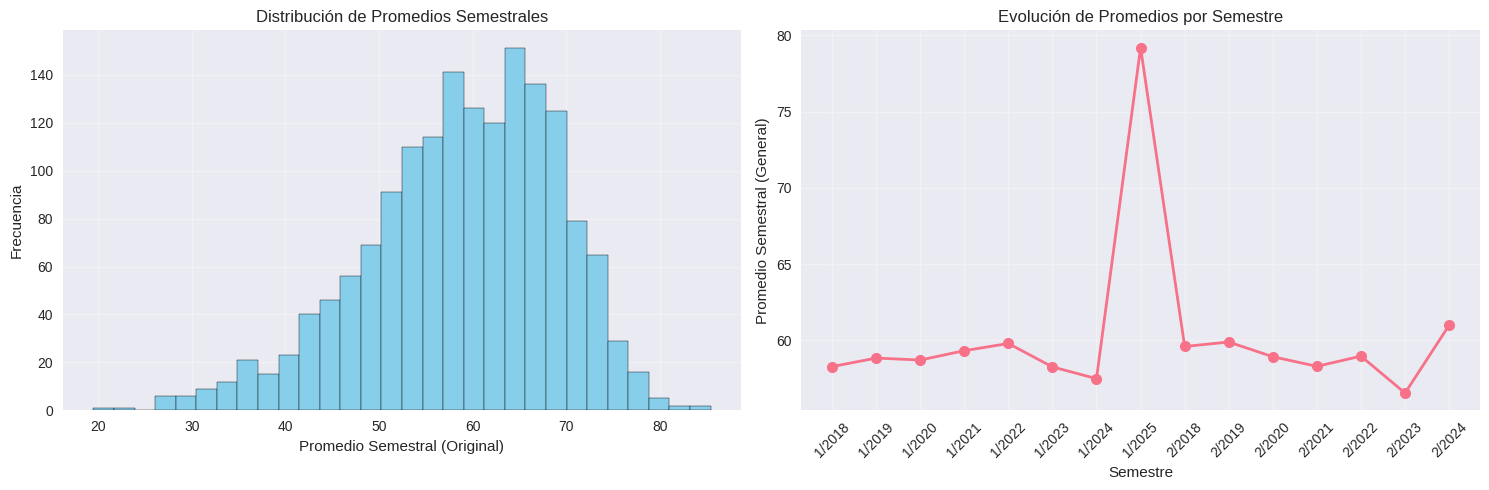

In [ ]:
# NOTA: Debes proporcionar la ruta a tu archivo CSV
# Ejemplo: csv_path = 'ruta/a/tu/dataset_estudiantes.csv'
csv_path = '/content/drive/MyDrive/IA2/ProyectoFinal/dataset_completo.csv'
# Parámetros de la ventana
SEQ_LEN = 3      # Usar 3 semestres de historia
PRED_LEN = 1     # Predecir 1 semestre adelante

try:
    # MODIFICADO: Recibir X_hist_data y X_future_data
    X_hist_data, X_future_data, y_data, student_ids, df_processed, metadata = load_and_prepare_student_data(
        csv_path, seq_len=3, pred_len=1
    )

    # ... (prints de metadata, sin cambios) ...
    print("\n" + "="*80)
    print("MUESTRA DEL DATASET PROCESADO (AGREGADO POR SEMESTRE)")
    print("="*80)
    # Mostramos las 5 primeras de las columnas originales y escaladas para comparar
    print(df_processed[['ID_Estudiante', 'Semestre', 'Promedio_Semestral_Original', 'Promedio_Semestral', 'Tasa_Aprobacion']].head())


    # ==========================================================
    # --- INICIO DE LA CORRECCIÓN DE GRÁFICAS ---
    # ==========================================================
    print("\n" + "="*80)
    print("ESTADÍSTICAS DEL DATASET")
    print("="*80)
    print(f"Total de estudiantes: {metadata['num_students']}")
    print(f"Total de registros (semestres-estudiante): {len(df_processed)}")
    print(f"Semestres únicos: {df_processed['Semestre'].nunique()}")

    # Visualización de notas (MODIFICADO a Promedio_Semestral_Original)
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    # USAR LA COLUMNA ORIGINAL
    plt.hist(df_processed['Promedio_Semestral_Original'], bins=30, color='skyblue', edgecolor='black')
    plt.xlabel('Promedio Semestral (Original)')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Promedios Semestrales')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    # USAR LA COLUMNA ORIGINAL
    promedio_por_semestre = df_processed.groupby('Semestre')['Promedio_Semestral_Original'].mean().sort_index()
    plt.plot(range(len(promedio_por_semestre)), promedio_por_semestre.values,
             marker='o', linewidth=2, markersize=8)
    plt.xlabel('Semestre')
    plt.ylabel('Promedio Semestral (General)')
    plt.title('Evolución de Promedios por Semestre')
    plt.xticks(range(len(promedio_por_semestre)), promedio_por_semestre.index, rotation=45)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    # ==========================================================
    # --- FIN DE LA CORRECCIÓN DE GRÁFICAS ---
    # ==========================================================

except FileNotFoundError:
    print(f"\n❌ ERROR: No se encontró el archivo '{csv_path}'")
    # ... (resto del except, sin cambios) ...
    raise

In [ ]:

# Configuración de datos para el modelo (MODIFICADO)
num_historical_vars = X_hist_data.shape[2]
num_future_vars = X_future_data.shape[2]
categorical_indices = []

# División train/test (80/20) (MODIFICADO)
train_size = int(0.8 * len(y_data))

X_train_hist, X_test_hist = X_hist_data[:train_size], X_hist_data[train_size:]
X_train_future, X_test_future = X_future_data[:train_size], X_future_data[train_size:]
y_train, y_test = y_data[:train_size], y_data[train_size:]

# Convertir a tensores de PyTorch (MODIFICADO)
X_train_hist_tensor = torch.FloatTensor(X_train_hist).to(device)
X_train_future_tensor = torch.FloatTensor(X_train_future).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_test_hist_tensor = torch.FloatTensor(X_test_hist).to(device)
X_test_future_tensor = torch.FloatTensor(X_test_future).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

print(f"\n{'='*80}")
print("DIVISIÓN DE DATOS")
model_config = {
    'num_static_vars': 0,
    'num_historical_vars': num_historical_vars,
    'num_future_vars': num_future_vars,
    'sequence_length': SEQ_LEN,
    'prediction_length': PRED_LEN,
    'hidden_size': 64,
    'num_heads': 4,
    'num_quantiles': 3,  # Percentiles 10%, 50%, 90%
    'dropout': 0.1,
    'categorical_indices': categorical_indices,
    'vocab_sizes': []
}

# Inicializar modelo
model = TemporalFusionTransformer(**model_config).to(device)
total_params = sum(p.numel() for p in model.parameters())

print(f"\n{'='*80}")
print("ARQUITECTURA DEL MODELO INICIALIZADA")
print(f"{'='*80}")
print(f"Parámetros entrenables: {total_params:,}")
print(f"Variables históricas: {num_historical_vars}")
print(f"Variables futuras (pistas): {num_future_vars}")

# Configuración de entrenamiento
quantiles = [0.1, 0.5, 0.9]
criterion = QuantileLoss(quantiles)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # LR INICIAL CORRECTO
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)


DIVISIÓN DE DATOS

ARQUITECTURA DEL MODELO INICIALIZADA
Parámetros entrenables: 410,859
Variables históricas: 6
Variables futuras (pistas): 2


In [ ]:
def train_model(model, X_train_hist, X_train_future, y_train, criterion, optimizer, scheduler,
                num_epochs=100, batch_size=32):
    """
    Función de entrenamiento del modelo TFT para estudiantes
    """
    model.train()
    train_losses = []

    print(f"\n{'='*80}")
    print("INICIANDO ENTRENAMIENTO")
    print(f"{'='*80}")
    print(f"Épocas: {num_epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate inicial: {optimizer.param_groups[0]['lr']}")

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0

        # Iterar en batches
        for batch_idx in range(0, len(X_train_hist), batch_size):
            end_idx = min(batch_idx + batch_size, len(X_train_hist))
            batch_X_hist = X_train_hist[batch_idx:end_idx]
            batch_X_future = X_train_future[batch_idx:end_idx] # Nuevo
            batch_y = y_train[batch_idx:end_idx]

            # Forward pass
            optimizer.zero_grad()
            predictions, attention_weights = model(batch_X_hist, batch_X_future)

            # Calcular pérdida
            loss = criterion(predictions, batch_y)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        # Promedio de pérdida de la época
        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)

        # Actualizar learning rate
        scheduler.step(avg_loss)

        # Mostrar progreso
        if (epoch + 1) % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Época [{epoch+1}/{num_epochs}], '
                  f'Pérdida: {avg_loss:.6f}, '
                  f'LR: {current_lr:.6f}')

    print(f"\n{'='*80}")
    print("ENTRENAMIENTO COMPLETADO")
    print(f"{'='*80}")
    print(f"Pérdida final: {train_losses[-1]:.6f}")
    return train_losses


INICIANDO ENTRENAMIENTO
Épocas: 150
Batch size: 32
Learning rate inicial: 0.001
Época [10/150], Pérdida: 0.688699, LR: 0.001000
Época [20/150], Pérdida: 0.565543, LR: 0.001000
Época [30/150], Pérdida: 0.369382, LR: 0.001000
Época [40/150], Pérdida: 0.243335, LR: 0.001000
Época [50/150], Pérdida: 0.219125, LR: 0.001000
Época [60/150], Pérdida: 0.198625, LR: 0.001000
Época [70/150], Pérdida: 0.131391, LR: 0.001000
Época [80/150], Pérdida: 0.136436, LR: 0.001000
Época [90/150], Pérdida: 0.113177, LR: 0.001000
Época [100/150], Pérdida: 0.140455, LR: 0.001000
Época [110/150], Pérdida: 0.074929, LR: 0.000500
Época [120/150], Pérdida: 0.069529, LR: 0.000250
Época [130/150], Pérdida: 0.054335, LR: 0.000250
Época [140/150], Pérdida: 0.049228, LR: 0.000125
Época [150/150], Pérdida: 0.038731, LR: 0.000125

ENTRENAMIENTO COMPLETADO
Pérdida final: 0.038731


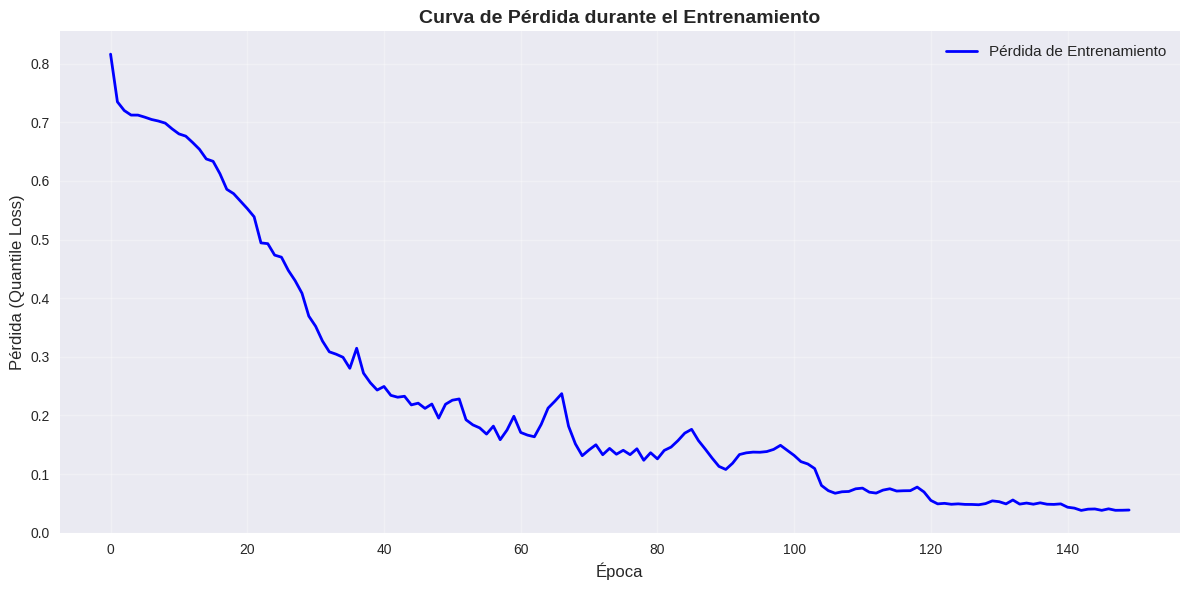

In [ ]:
# Entrenar modelo
train_losses = train_model(
    model, X_train_hist_tensor, X_train_future_tensor, y_train_tensor,
    criterion, optimizer, scheduler,
    num_epochs=150, batch_size=32
)

# Visualizar curva de entrenamiento
plt.figure(figsize=(12, 6))
plt.plot(train_losses, 'b-', linewidth=2, label='Pérdida de Entrenamiento')
plt.title('Curva de Pérdida durante el Entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Época', fontsize=12)
plt.ylabel('Pérdida (Quantile Loss)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_model(model, X_test_hist, X_test_future, y_test, target_scaler, batch_size=32):
  model.eval()
  all_predictions = []

  with torch.no_grad():
    for i in range(0, len(X_test_hist), batch_size):
      end_idx = min(i + batch_size, len(X_test_hist))
      batch_X_hist = X_test_hist[i:end_idx]
      batch_X_future = X_test_future[i:end_idx] # Nuevo

      predictions, attention_weights = model(batch_X_hist, batch_X_future)

      all_predictions.append(predictions.cpu().numpy())
  # Concatenar todas las predicciones
  predictions = np.concatenate(all_predictions, axis=0)

  # Desnormalizar predicciones
  predictions_reshaped = predictions.reshape(-1, 1)
  predictions_denorm = target_scaler.inverse_transform(predictions_reshaped).reshape(predictions.shape)

  # Desnormalizar datos reales
  y_test_reshaped = y_test.reshape(-1, 1)
  y_test_denorm = target_scaler.inverse_transform(y_test_reshaped).reshape(y_test.shape)

  return predictions_denorm, y_test_denorm, attention_weights

# Evaluar modelo
print(f"\n{'='*80}")
print("EVALUANDO MODELO EN DATOS DE PRUEBA")
print(f"{'='*80}")

predictions, y_actual, attention_weights = evaluate_model(
    model, X_test_hist_tensor, X_test_future_tensor, y_test_tensor.cpu().numpy(),
    metadata['target_scaler'], batch_size=32
)

print(f"Predicciones generadas: {predictions.shape}")
print(f"Valores reales: {y_actual.shape}")


EVALUANDO MODELO EN DATOS DE PRUEBA
Predicciones generadas: (201, 1, 3)
Valores reales: (201, 1, 1)


In [ ]:
def plot_predictions(predictions, y_actual, num_samples=5):
    """
    Visualiza las predicciones del modelo TFT vs valores reales
    (Ahora prediciendo Promedio Semestral)
    """
    plt.style.use('seaborn-v0_8')

    # Asegurarse de que hay suficientes muestras para graficar
    if len(predictions) == 0:
        print("No hay predicciones para graficar.")
        return
    num_samples = min(num_samples, len(predictions))

    fig, axes = plt.subplots(num_samples, 1, figsize=(15, 4*num_samples), squeeze=False)
    indices = np.random.choice(len(predictions), num_samples, replace=False)

    for idx, sample_idx in enumerate(indices):
        ax = axes[idx, 0]
        pred_quantiles = predictions[sample_idx]
        actual = y_actual[sample_idx].squeeze(-1)
        time_steps = np.arange(len(actual))

        # Plotting points for actual and median prediction
        ax.plot(time_steps, actual, 'bo', label='Promedio Real', markersize=10, zorder=3)
        ax.plot(time_steps, pred_quantiles[:, 1], 'rs', label='Predicción (Mediana)', markersize=10, zorder=3)

        # To visualize the interval for a single prediction point (as PRED_LEN is 1)
        x_fill_center = time_steps[0]
        x_fill_width = 0.4 # Adjust width as needed for visual clarity
        x_fill_min = x_fill_center - x_fill_width / 2
        x_fill_max = x_fill_center + x_fill_width / 2

        ax.fill_between([x_fill_min, x_fill_max],
                        [pred_quantiles[0, 0], pred_quantiles[0, 0]], # Q10 values
                        [pred_quantiles[0, 2], pred_quantiles[0, 2]], # Q90 values
                        color='red', alpha=0.3, label='Intervalo 80% (Q10-Q90)', zorder=2) # Made alpha higher and added zorder

        ax.axhline(y=51, color='green', linestyle=':', linewidth=2, label='Línea de Aprobación (51)', zorder=1)

        error = np.abs(actual - pred_quantiles[:, 1])
        ax.set_title(f'Muestra {sample_idx + 1} - Error Absoluto: {error.mean():.2f}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Tiempo (Semestres Futuros)', fontsize=11)
        ax.set_ylabel('Promedio Semestral', fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 105])
        ax.set_xticks([0]) # Only show x-tick at 0 for single prediction
        ax.set_xticklabels(['Próximo Semestre']) # Label it

    plt.tight_layout()
    plt.show()

def plot_additional_visualizations(predictions, y_actual):
    """
    Genera gráficos adicionales para evaluar la precisión del modelo
    """
    if len(predictions) == 0:
        print("No hay datos para las visualizaciones adicionales.")
        return

    plt.style.use('seaborn-v0_8')
    pred_median = predictions[:, :, 1]
    y_actual_squeezed = y_actual.squeeze(-1)

    fig = plt.figure(figsize=(18, 5))

    # 1. Gráfico de dispersión
    ax1 = plt.subplot(1, 3, 1)
    scatter = ax1.scatter(y_actual_squeezed.flatten(), pred_median.flatten(),
                          alpha=0.6, c=y_actual_squeezed.flatten(),
                          cmap='viridis', s=50, edgecolors='black', linewidth=0.5)
    ax1.plot([y_actual_squeezed.min(), y_actual_squeezed.max()],
             [y_actual_squeezed.min(), y_actual_squeezed.max()],
             'r--', linewidth=2.5, label='Línea Ideal (y=x)')
    ax1.axvline(x=51, color='green', linestyle=':', linewidth=2, alpha=0.7, label='Aprobación')
    ax1.axhline(y=51, color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax1.set_xlabel('Promedios Reales', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Predicciones (Mediana)', fontsize=12, fontweight='bold')
    ax1.set_title('Predicciones vs Valores Reales', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax1, label='Promedio Real')

    # 2. Histograma de Errores
    ax2 = plt.subplot(1, 3, 2)
    errors = np.abs(pred_median - y_actual_squeezed).flatten()
    ax2.hist(errors, bins=40, color='purple', alpha=0.7, edgecolor='black')
    ax2.axvline(x=errors.mean(), color='red', linestyle='--',
                linewidth=2.5, label=f'Error Promedio: {errors.mean():.2f}')
    ax2.axvline(x=np.median(errors), color='orange', linestyle='--',
                linewidth=2.5, label=f'Mediana: {np.median(errors):.2f}')
    ax2.set_xlabel('Error Absoluto (Puntos)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
    ax2.set_title('Distribución de Errores Absolutos', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. Matriz de Confusión
    ax3 = plt.subplot(1, 3, 3)
    pred_classes = (pred_median.flatten() >= 51).astype(int)
    actual_classes = (y_actual_squeezed.flatten() >= 51).astype(int)
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(actual_classes, pred_classes)
    im = ax3.imshow(cm, interpolation='nearest', cmap='Blues')
    ax3.figure.colorbar(im, ax=ax3)
    classes = ['Reprobado (<51)', 'Aprobado (\u226551)']
    tick_marks = np.arange(len(classes))
    ax3.set_xticks(tick_marks)
    ax3.set_yticks(tick_marks)
    ax3.set_xticklabels(classes, fontsize=10)
    ax3.set_yticklabels(classes, fontsize=10)
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax3.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center", fontsize=14, fontweight='bold',
                     color="white" if cm[i, j] > thresh else "black")
    ax3.set_ylabel('Clase Real', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Clase Predicha', fontsize=12, fontweight='bold')
    ax3.set_title('Matriz de Confusión\n(Promedio Aprobado/Reprobado)', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()


EVALUANDO MODELO EN DATOS DE PRUEBA
Predicciones generadas: (201, 1, 3)
Valores reales: (201, 1, 1)

1. Predicciones vs Valores Reales (5 muestras)...


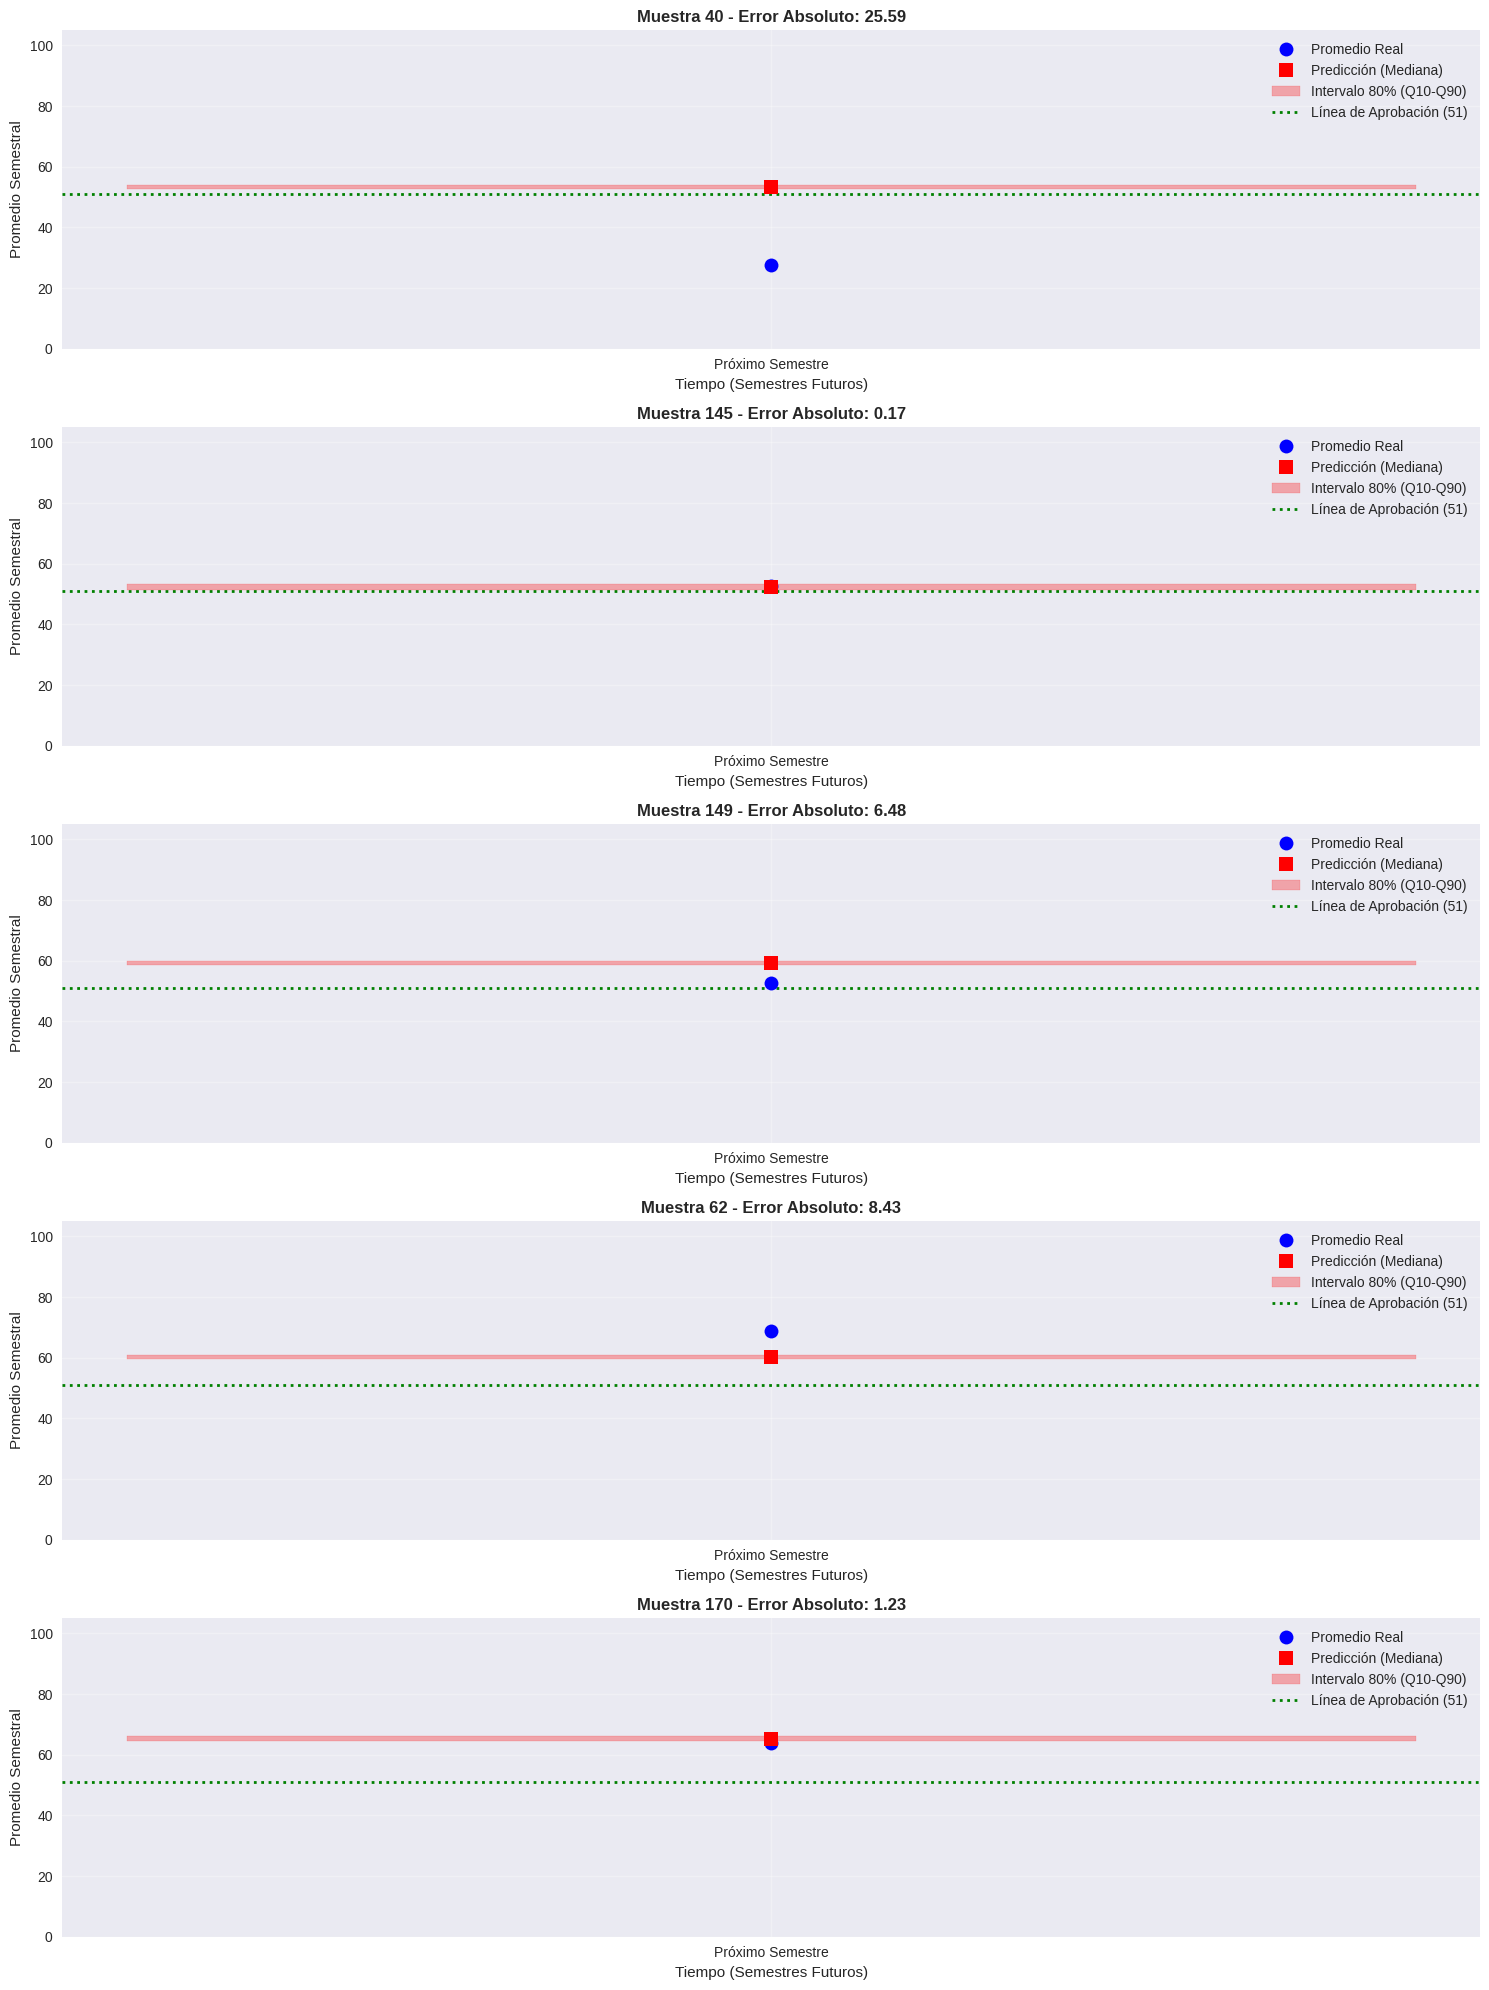

In [ ]:
print(f"\n{'='*80}")
print("EVALUANDO MODELO EN DATOS DE PRUEBA")
print(f"{'='*80}")

predictions, y_actual, attention_weights = evaluate_model(
    model, X_test_hist_tensor, X_test_future_tensor, y_test_tensor.cpu().numpy(),
    metadata['target_scaler'], batch_size=32
)

print(f"Predicciones generadas: {predictions.shape}")
print(f"Valores reales: {y_actual.shape}")

print("\n1. Predicciones vs Valores Reales (5 muestras)...")
plot_predictions(predictions, y_actual, num_samples=5)


In [ ]:
def predict_next_semester(model, student_id, df_original, metadata,
                          future_inputs_dict,
                          num_historical_semesters=3):
    """
    MODIFICADO:
    Predice el PROMEDIO del siguiente semestre para un estudiante específico,
    DADAS las "pistas" futuras (ej. Carga Académica).
    """
    model.eval()

    # Filtrar datos del estudiante (del DF original)
    student_data_raw = df_original[df_original['ID_Estudiante'] == student_id].copy()

    if len(student_data_raw) == 0:
        print(f"Error: No se encontraron datos para el estudiante {student_id}")
        return None

    # --- INICIO DE LA LÓGICA DE AGREGACIÓN (replicada) ---
    student_data_raw['Semestre_Num'] = student_data_raw['Semestre'].str.split('/').apply(
        lambda x: int(x[1]) * 10 + int(x[0])
    )
    def tasa_aprobacion(x):
        if len(x) == 0: return 0
        return ((x == 'A') | (x == 'C')).sum() / len(x)
    def num_reprobadas(x):
        return ((x == 'R') | (x == 'B')).sum()
    agg_funcs = {
        'Promedio_Semestral': 'first',
        'Carga_Académica': 'first',
        'Semestre_Correspondiente': 'mean',
        'Nota_Final': ['mean', 'std'],
        'Estado': [tasa_aprobacion, num_reprobadas],
        'Segunda_Instancia': 'sum'
    }
    student_data_agg = student_data_raw.groupby(['ID_Estudiante', 'Semestre', 'Semestre_Num']).agg(agg_funcs).reset_index()
    student_data_agg.columns = ['_'.join(col).strip('_') for col in student_data_agg.columns.values]
    student_data_agg = student_data_agg.rename(columns={
        'Promedio_Semestral_first': 'Promedio_Semestral',
        'Carga_Académica_first': 'Carga_Académica',
        'Semestre_Correspondiente_mean': 'Promedio_Semestre_Corresp',
        'Nota_Final_mean': 'Promedio_Notas',
        'Nota_Final_std': 'Std_Notas',
        'Estado_tasa_aprobacion': 'Tasa_Aprobacion',
        'Estado_num_reprobadas': 'Num_Reprobadas',
        'Segunda_Instancia_sum': 'Num_Segunda_Instancia'
    })
    student_data_agg['Std_Notas'] = student_data_agg['Std_Notas'].fillna(0)
    student_data_agg = student_data_agg.sort_values('Semestre_Num')
    # --- FIN DE LA LÓGICA DE AGREGACIÓN ---

    print(f"\n{'='*80}")
    print(f"PREDICCIÓN PARA ESTUDIANTE {student_id}")
    print(f"{'='*80}")
    print(f"\nHistorial del estudiante:")
    print(f"  • Total de registros (materias): {len(student_data_raw)}")
    print(f"  • Total de registros (semestres): {len(student_data_agg)}")
    print(f"  • Último semestre: {student_data_agg['Semestre'].iloc[-1]}")

    if len(student_data_agg) < num_historical_semesters:
        print(f"\n Advertencia: El estudiante solo tiene {len(student_data_agg)} semestres.")
        num_historical_semesters = len(student_data_agg)

    # --- INICIO DE PREPARACIÓN DE DATOS ---

    # 1. Preparar datos históricos (X_hist)
    recent_data = student_data_agg.tail(num_historical_semesters).copy()
    recent_data_original = recent_data.copy()

    historical_cols = metadata['historical_cols']
    recent_data[historical_cols] = metadata['historical_scaler'].transform(recent_data[historical_cols])
    sequence_hist = recent_data[historical_cols].values

    if len(sequence_hist) < model.sequence_length:
        padding = np.zeros((model.sequence_length - len(sequence_hist), sequence_hist.shape[1]))
        sequence_hist = np.vstack([padding, sequence_hist])
    else:
        sequence_hist = sequence_hist[-model.sequence_length:]
    X_hist_tensor = torch.FloatTensor(sequence_hist).unsqueeze(0).to(device)

    # 2. Preparar datos futuros (X_future)
    if future_inputs_dict is None:
        print("Error: Se deben proporcionar 'future_inputs_dict'.")
        return None

    print(f"\n{'='*80}")
    print(f"PISTAS PARA LA PREDICCIÓN")
    print(f"{'='*80}")
    print(f"  • Carga Académica (Pista): {future_inputs_dict.get('Carga_Académica')}")
    print(f"  • Nivel de Materias (Pista): {future_inputs_dict.get('Promedio_Semestre_Corresp')}")

    future_df = pd.DataFrame([future_inputs_dict])
    future_cols = metadata['future_cols']
    future_df = future_df[future_cols]
    future_data_scaled = metadata['future_scaler'].transform(future_df)
    X_future_tensor = torch.FloatTensor(future_data_scaled).unsqueeze(0).to(device)

    # 3. Hacer predicción
    with torch.no_grad():
        predictions, _ = model(X_hist_tensor, X_future_tensor)
    # --- FIN DE PREPARACIÓN Y PREDICCIÓN ---

    # Desnormalizar
    predictions_np = predictions.cpu().numpy()
    predictions_reshaped = predictions_np.reshape(-1, 1)
    predictions_denorm = metadata['target_scaler'].inverse_transform(predictions_reshaped).reshape(predictions_np.shape)
    predictions_denorm = np.clip(predictions_denorm, 0, 100)

    pred_q10 = predictions_denorm[0, 0, 0]
    pred_median = predictions_denorm[0, 0, 1]
    pred_q90 = predictions_denorm[0, 0, 2]
    estado_predicho = "✅ APROBADO" if pred_median >= 51 else "❌ REPROBADO"

    # Estadísticas
    promedio_historico_semestral = student_data_agg['Promedio_Semestral'].mean()
    prom_max = student_data_agg['Promedio_Semestral'].max()
    prom_min = student_data_agg['Promedio_Semestral'].min()

    # Mostrar resultados
    print(f"\n{'='*80}")
    print(f"ESTADÍSTICAS HISTÓRICAS (Nivel Semestre)")
    print(f"{'='*80}")
    print(f"  • Promedio histórico (semestral): {promedio_historico_semestral:.2f}")
    print(f"  • Mejor promedio semestral:      {prom_max:.2f}")
    print(f"  • Peor promedio semestral:       {prom_min:.2f}")

    print(f"\n{'='*80}")
    print(f"PREDICCIÓN PARA EL PRÓXIMO SEMESTRE (con pistas dadas)")
    print(f"{'='*80}")
    print(f"  • Promedio predicho (mediana): {pred_median:.2f}")
    print(f"  • Estado predicho:             {estado_predicho}")
    print(f"  • Intervalo de confianza:")
    print(f"    - Límite inferior (Q10): {pred_q10:.2f}")
    print(f"    - Límite superior (Q90): {pred_q90:.2f}")

    if pred_median >= 70:
        riesgo = "🟢 BAJO - Excelente proyección"
    elif pred_median >= 51:
        riesgo = "🟡 MEDIO - Aprobación probable con esfuerzo"
    else:
        riesgo = "🔴 ALTO - Requiere intervención inmediata"
    print(f"\n  • Nivel de riesgo:             {riesgo}")

    print(f"\n{'='*80}")
    print(f"ANÁLISIS DE CARACTERÍSTICAS (Último Semestre Registrado)")
    print(f"{'='*80}")
    last_semester = recent_data_original.iloc[-1]
    print(f"  • Promedio Semestral (Histórico): {last_semester['Promedio_Semestral']:.2f}")
    print(f"  • Tasa de Aprobación (Semestre): {last_semester['Tasa_Aprobacion']*100:.1f}%")
    print(f"  • Materias Reprobadas (Semestre): {last_semester['Num_Reprobadas']:.0f}")
    print(f"\n{'='*80}")

    return {
        'student_id': student_id,
        'prediction_median': pred_median,
        'prediction_q10': pred_q10,
        'prediction_q90': pred_q90,
    }

In [ ]:
def predict_new_student(model, csv_path_new_student, metadata,
                        future_inputs_dict,
                        num_historical_semesters=3):
    """
    MODIFICADO:
    Predice el PROMEDIO del siguiente semestre para un estudiante NUEVO,
    aplicando la lógica de agregación y usando pistas futuras.
    """
    model.eval()

    print(f"\n{'='*80}")
    print(f"CARGANDO DATOS DEL NUEVO ESTUDIANTE")
    print(f"{'='*80}")

    try:
        new_student_data_raw = pd.read_csv(csv_path_new_student, sep=';')
        print(f"CSV cargado exitosamente: {len(new_student_data_raw)} registros (nivel materia) encontrados")
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{csv_path_new_student}'")
        return None
    except Exception as e:
        print(f"Error al cargar el archivo: {str(e)}")
        return None

    if len(new_student_data_raw) == 0:
        print(f"Error: El CSV está vacío")
        return None

    student_id = new_student_data_raw['ID_Estudiante'].iloc[0]

    # --- INICIO DE LA LÓGICA DE AGREGACIÓN ---
    new_student_data_raw['Semestre_Num'] = new_student_data_raw['Semestre'].str.split('/').apply(
        lambda x: int(x[1]) * 10 + int(x[0])
    )
    def tasa_aprobacion(x):
        if len(x) == 0: return 0
        return ((x == 'A') | (x == 'C')).sum() / len(x)
    def num_reprobadas(x):
        return ((x == 'R') | (x == 'B')).sum()
    agg_funcs = {
        'Promedio_Semestral': 'first',
        'Carga_Académica': 'first',
        'Semestre_Correspondiente': 'mean',
        'Nota_Final': ['mean', 'std'],
        'Estado': [tasa_aprobacion, num_reprobadas],
        'Segunda_Instancia': 'sum'
    }
    new_student_data_agg = new_student_data_raw.groupby(['ID_Estudiante', 'Semestre', 'Semestre_Num']).agg(agg_funcs).reset_index()
    new_student_data_agg.columns = ['_'.join(col).strip('_') for col in new_student_data_agg.columns.values]
    new_student_data_agg = new_student_data_agg.rename(columns={
        'Promedio_Semestral_first': 'Promedio_Semestral',
        'Carga_Académica_first': 'Carga_Académica',
        'Semestre_Correspondiente_mean': 'Promedio_Semestre_Corresp',
        'Nota_Final_mean': 'Promedio_Notas',
        'Nota_Final_std': 'Std_Notas',
        'Estado_tasa_aprobacion': 'Tasa_Aprobacion',
        'Estado_num_reprobadas': 'Num_Reprobadas',
        'Segunda_Instancia_sum': 'Num_Segunda_Instancia'
    })
    new_student_data_agg['Std_Notas'] = new_student_data_agg['Std_Notas'].fillna(0)
    new_student_data_agg = new_student_data_agg.sort_values('Semestre_Num')
    # --- FIN DE LA LÓGICA DE AGREGACIÓN ---

    print(f"\n{'='*80}")
    print(f"PREDICCIÓN PARA ESTUDIANTE NUEVO (ID: {student_id})")
    print(f"{'='*80}")
    print(f"\nHistorial del estudiante:")
    print(f"  • Total de registros (semestres): {len(new_student_data_agg)}")
    print(f"  • Último semestre: {new_student_data_agg['Semestre'].iloc[-1]}")

    if len(new_student_data_agg) < num_historical_semesters:
        num_historical_semesters = len(new_student_data_agg)

    # --- INICIO DE PREPARACIÓN DE DATOS ---

    # 1. Preparar datos históricos (X_hist)
    recent_data = new_student_data_agg.tail(num_historical_semesters).copy()
    historical_cols = metadata['historical_cols']
    recent_data[historical_cols] = metadata['historical_scaler'].transform(recent_data[historical_cols])
    sequence_hist = recent_data[historical_cols].values

    if len(sequence_hist) < model.sequence_length:
        padding = np.zeros((model.sequence_length - len(sequence_hist), sequence_hist.shape[1]))
        sequence_hist = np.vstack([padding, sequence_hist])
    else:
        sequence_hist = sequence_hist[-model.sequence_length:]
    X_hist_tensor = torch.FloatTensor(sequence_hist).unsqueeze(0).to(device)

    # 2. Preparar datos futuros (X_future)
    if future_inputs_dict is None:
        print("Error: Se deben proporcionar 'future_inputs_dict'.")
        return None

    print(f"\n{'='*80}")
    print(f"🔮 PISTAS PARA LA PREDICCIÓN")
    print(f"{'='*80}")
    print(f"  • Carga Académica (Pista): {future_inputs_dict.get('Carga_Académica')}")
    print(f"  • Nivel de Materias (Pista): {future_inputs_dict.get('Promedio_Semestre_Corresp')}")

    future_df = pd.DataFrame([future_inputs_dict])
    future_cols = metadata['future_cols']
    future_df = future_df[future_cols]
    future_data_scaled = metadata['future_scaler'].transform(future_df)
    X_future_tensor = torch.FloatTensor(future_data_scaled).unsqueeze(0).to(device)

    # 3. Hacer predicción
    with torch.no_grad():
        predictions, _ = model(X_hist_tensor, X_future_tensor)
    # --- FIN DE PREPARACIÓN Y PREDICCIÓN ---

    # Desnormalizar
    predictions_np = predictions.cpu().numpy()
    predictions_denorm = metadata['target_scaler'].inverse_transform(predictions_np.reshape(-1, 1)).reshape(predictions_np.shape)
    predictions_denorm = np.clip(predictions_denorm, 0, 100)

    pred_q10 = predictions_denorm[0, 0, 0]
    pred_median = predictions_denorm[0, 0, 1]
    pred_q90 = predictions_denorm[0, 0, 2]
    estado_predicho = "APROBADO" if pred_median >= 51 else "❌ REPROBADO"

    # Estadísticas
    promedio_historico_semestral = new_student_data_agg['Promedio_Semestral'].mean()
    print(f"\n{'='*80}")
    print(f"ESTADÍSTICAS HISTÓRICAS (Nivel Semestre)")
    print(f"{'='*80}")
    print(f"  • Promedio histórico (semestral): {promedio_historico_semestral:.2f}")

    print(f"\n{'='*80}")
    print(f"PREDICCIÓN PARA EL PRÓXIMO SEMESTRE (con pistas dadas)")
    print(f"{'='*80}")
    print(f"  • Promedio predicho (mediana): {pred_median:.2f}")
    print(f"  • Estado predicho:             {estado_predicho}")
    print(f"  • Intervalo de confianza:")
    print(f"    - Límite inferior (Q10): {pred_q10:.2f}")
    print(f"    - Límite superior (Q90): {pred_q90:.2f}")
    print(f"\n{'='*80}")

    return {
        'student_id': student_id,
        'prediction_median': pred_median,
        'is_new_student': True
    }

In [ ]:
# --- PREDICCIÓN ESTUDIANTE EXISTENTE (EJ. DEL DATASET DE ENTRENAMIENTO) ---
print("\n" + "="*80)
print("GENERANDO PREDICCIÓN PARA ESTUDIANTE EXISTENTE")
print("="*80)

# CAMBIA ESTE ID POR EL ESTUDIANTE QUE QUIERAS PREDECIR
ESTUDIANTE_ID = 1 # ID del dataset sintético

# Usa la misma ruta que usaste para entrenar
csv_path_original = '/content/drive/MyDrive/IA2/ProyectoFinal/dataset_completo.csv'

# Define las "pistas" para el próximo semestre
pistas_estudiante_existente = {
    'Carga_Académica': 4,
    'Promedio_Semestre_Corresp': 8 # Asumiendo que tomará materias de 8vo semestre
}

try:
    df_original = pd.read_csv(csv_path_original, sep=';')
    result = predict_next_semester(
        model=model,
        student_id=ESTUDIANTE_ID,
        df_original=df_original,
        metadata=metadata,
        future_inputs_dict=pistas_estudiante_existente,
        num_historical_semesters=SEQ_LEN
    )

    # --- Prueba "What-if" ---
    print("\n--- PRUEBA 'WHAT-IF' ---")
    print(f"¿Qué pasaría si el Estudiante {ESTUDIANTE_ID} toma una carga más pesada (7 materias)?")
    pistas_pesadas = {
        'Carga_Académica': 7,
        'Promedio_Semestre_Corresp': 5
    }
    _ = predict_next_semester(
        model=model,
        student_id=ESTUDIANTE_ID,
        df_original=df_original,
        metadata=metadata,
        future_inputs_dict=pistas_pesadas,
        num_historical_semesters=SEQ_LEN
    )
except Exception as e:
    print(f"\nERROR al predecir para estudiante existente: {e}")


# --- PREDICCIÓN ESTUDIANTE NUEVO ---
print("\n" + "="*80)
print("PREDICCIÓN PARA ESTUDIANTE NUEVO (NO EN DATASET DE ENTRENAMIENTO)")
print("="*80)

# RUTA AL CSV DEL NUEVO ESTUDIANTE
csv_nuevo_estudiante = '/content/drive/MyDrive/IA2/ProyectoFinal/nuevo_estudiante2.csv'  # CAMBIA ESTA RUTA

pistas_futuras_nuevo = {
    'Carga_Académica': 5,
    'Promedio_Semestre_Corresp': 6
}

try:
    result_new = predict_new_student(
        model=model,
        csv_path_new_student=csv_nuevo_estudiante,
        metadata=metadata,
        future_inputs_dict=pistas_futuras_nuevo,
        num_historical_semesters=SEQ_LEN
    )
except Exception as e:
    print(f"\n ERROR AL PREDECIR PARA ESTUDIANTE NUEVO: {e}")


GENERANDO PREDICCIÓN PARA ESTUDIANTE EXISTENTE

PREDICCIÓN PARA ESTUDIANTE 1

Historial del estudiante:
  • Total de registros (materias): 33
  • Total de registros (semestres): 6
  • Último semestre: 2/2024

PISTAS PARA LA PREDICCIÓN
  • Carga Académica (Pista): 4
  • Nivel de Materias (Pista): 8

ESTADÍSTICAS HISTÓRICAS (Nivel Semestre)
  • Promedio histórico (semestral): 67.88
  • Mejor promedio semestral:      85.40
  • Peor promedio semestral:       51.50

PREDICCIÓN PARA EL PRÓXIMO SEMESTRE (con pistas dadas)
  • Promedio predicho (mediana): 61.27
  • Estado predicho:             ✅ APROBADO
  • Intervalo de confianza:
    - Límite inferior (Q10): 60.49
    - Límite superior (Q90): 61.96

  • Nivel de riesgo:             🟡 MEDIO - Aprobación probable con esfuerzo

ANÁLISIS DE CARACTERÍSTICAS (Último Semestre Registrado)
  • Promedio Semestral (Histórico): 85.40
  • Tasa de Aprobación (Semestre): 100.0%
  • Materias Reprobadas (Semestre): 0


--- PRUEBA 'WHAT-IF' ---
¿Qué pasaría 

In [ ]:
import joblib

# 1. Definir el nombre del archivo para los pesos del modelo
model_path = 'tft_model_weights.pth'

# 2. Guardar el state_dict del modelo
# Esto guarda solo los pesos entrenados
torch.save(model.state_dict(), model_path)

# 3. Definir el nombre del archivo para los artefactos de preprocesamiento
metadata_path = 'tft_metadata.joblib'

# 4. Agrupar todos los artefactos necesarios en un solo diccionario
# ¡Esto es CRUCIAL! Necesitamos los scalers y el orden de las columnas.
metadata_to_save = {
    'historical_scaler': metadata['historical_scaler'],
    'future_scaler': metadata['future_scaler'],
    'target_scaler': metadata['target_scaler'],
    'historical_cols': metadata['historical_cols'],
    'future_cols': metadata['future_cols'],
    'model_config': model_config, # Guardamos la config para saber cómo re-crear el modelo
    'seq_len': SEQ_LEN
}

# 5. Guardar el diccionario de artefactos usando joblib
joblib.dump(metadata_to_save, metadata_path)

print(f"¡Modelo guardado en: {model_path}")
print(f"¡Artefactos (scalers/columnas) guardados en: {metadata_path}")

# 6. (Opcional) Descargarlos a tu PC local desde Colab
try:
    from google.colab import files
    files.download(model_path)
    files.download(metadata_path)
    print("Descargando archivos a tu máquina local...")
except ImportError:
    print("No estás en Colab. Archivos guardados localmente.")

¡Modelo guardado en: tft_model_weights.pth
¡Artefactos (scalers/columnas) guardados en: tft_metadata.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando archivos a tu máquina local...
